In [3]:
import torch
from score_models import ScoreModel, NCSNpp
from torchvision import transforms as T
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
import h5py

from pyro import distributions as dist

/home/aadam/environments/milex/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
path = "../../skirt64_grizy.h5"
file = h5py.File(path)

data = file["images"][:100, 0].reshape(100, 64**2)

In [25]:
data.shape

(100, 4096)

In [27]:
var = data.var(axis=1)
homo_data = data / var[:, None]**(1/2)

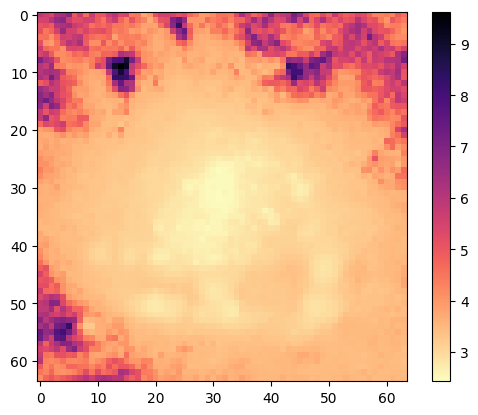

In [32]:
plt.imshow(homo_data[11].reshape(64, 64), cmap="magma_r")
plt.colorbar()

# Training a score model on images

For this tutorial, we will use a downsampled version of PROBES dataset (mainly to speed up training). 

## Creating a dataset

In [4]:
DTYPE = torch.float32
DEVICE = torch.device("cuda:0")


def covariance_matrix(size, slope, dtype=DTYPE , device=torch.device("cpu")):
    # Generate 2D grid of frequencies
    freqs_x = torch.fft.fftfreq(size[0], 1.0/size[0], dtype=dtype, device=device).view(-1, 1)
    freqs_y = torch.fft.fftfreq(size[1], 1.0/size[1], dtype=dtype, device=device).view(1, -1)
    freqs_r = torch.sqrt(freqs_x**2 + freqs_y**2)

    # Create the power spectrum
    power_spectrum = freqs_r**slope
    power_spectrum[0, 0] = 0.0  # Set the zero-frequency component to zero

    # Perform the inverse 2D Fourier transform
    cov_spatial = torch.fft.ifft2(power_spectrum).real

    # Compute the covariance matrix of size (n*m, n*m)
    rows, cols = np.indices(size)
    row_diff = rows.reshape(-1, 1) - rows.reshape(1, -1)
    col_diff = cols.reshape(-1, 1) - cols.reshape(1, -1)
    cov_matrix = cov_spatial[row_diff % size[0], col_diff % size[1]]

    return cov_matrix

slope = -2.5
pix = 64

Sigma_kappa_brown = covariance_matrix([pix, pix], slope=slope) / 10
mu_kappa_brown = torch.zeros(pix, pix)
Sigma_kappa_brown = (Sigma_kappa_brown.T + Sigma_kappa_brown)/2 + torch.eye(Sigma_kappa_brown.shape[0])*0.0001

scale_tril_kappa_brown = torch.as_tensor(np.linalg.cholesky(Sigma_kappa_brown), dtype=DTYPE, device=DEVICE)
mu_kappa_brown = torch.as_tensor(mu_kappa_brown, dtype=DTYPE, device=DEVICE)
Sigma_kappa_brown = torch.as_tensor(Sigma_kappa_brown, dtype=DTYPE, device=DEVICE)

p_0_kappa_brown = dist.MultivariateNormal(mu_kappa_brown.flatten(), scale_tril=scale_tril_kappa_brown)

prior_dist = torch.distributions.multivariate_normal.MultivariateNormal(mu_kappa_brown.flatten(), Sigma_kappa_brown)

In [5]:
prior_dist.sample().shape

torch.Size([4096])

In [16]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

class PROBES(torch.utils.data.Dataset):
    def __init__(self, path):
        self.file = h5py.File(path, "r")
        self.size = len(self.file["galaxies"])

    def __len__(self):
        return self.size
    
    def __getitem__(self, index):
        # # Load an image from the dataset (we use the g channel, others are r and z)
        # img = self.file["galaxies"][index, ..., 0]
        # # Load the image on GPU and add channel dimension (channels first)
        # img = torch.tensor(img.astype(np.float32)).unsqueeze(0).to(DEVICE)
        # # Apply some preprocessing: we saturate the images to diminish the effects of stars outshining some images in the set
        # img = torch.clamp(img, 0, 10)
        # # Downsample the image to 32x32
        # img = F.avg_pool2d(img, 8) # for 64x64, use a kernel size of 4 instead (2 for 128 etc.)
        
        img = prior_dist.sample()[None]
        return img
        

(-0.5, 31.5, 31.5, -0.5)

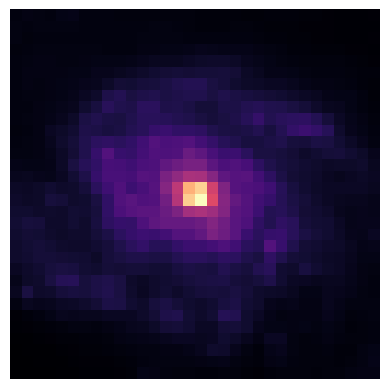

In [17]:
path = "../../probes.h5" # path to the probes dataset
dataset = PROBES(path)

# The dataset works similar to a list, from which we can access indexed elements
plt.imshow(dataset[101].squeeze().cpu(), cmap="magma")
plt.axis("off")

## Training the score model

In [18]:
# First, let's specify where to save the weights 
checkpoints_directory = "../models/score_model_probes32" 

Note: the directory score_model_probes32 doens not have to exist, it will be created when fit is called. If the directory exists, the method will look for training checkpoints and optimizer checkpoints to resume training from previous state. 

In [36]:
# Construct the architecture and the score model
channels = 1 # specifies the input channels
nf = 64 # number of filters
ch_mult = (1, 2, 2) # multiplicative factor of nf at each level of the unet (3 total, length of that list)
attention = True # Use attention in the bottleneck

net = NCSNpp(channels=channels, nf=nf, ch_mult=ch_mult, attention=attention)

# Specify the SDE parameters, we will use VP
# beta_min = 1e-2
# beta_max = 20
# epsilon = 1e-5

# model = ScoreModel(net, beta_min=beta_min, beta_max=beta_max, epsilon=epsilon)
sigma_min = 1e-4
sigma_max = 1e2

model = ScoreModel(net, sigma_min=sigma_min, sigma_max=sigma_max)

In [32]:
# Hyperparameters for training the score model

epochs = 200
batch_size = 16
learning_rate = 1e-4
n_iterations_in_epoch=100 # redefine an epoch to be 100 iteration to see more progress

# fit method returns a loss history for plotting
loss = model.fit(
    dataset, 
    epochs=epochs, 
    batch_size=batch_size, 
    learning_rate=learning_rate, 
    n_iterations_in_epoch=n_iterations_in_epoch,
    checkpoints_directory=checkpoints_directory, # specify where to save and load weights from 
    shuffle=False # Do not shuffle an h5 dataset. This slows down the loading the data tremendously (see h5py doc). This does not impact training at all. 
)
loss

Epoch 200 | Cost: 4.5e+00 |: 100%|██████████| 200/200 [25:19<00:00,  7.60s/it]

Finished training after 0.422 hours.


[108.09115111180978,
 12.16908532150032,
 10.810965988987176,
 8.75717468039934,
 7.90520607408627,
 6.820747600969418,
 7.91916430458542,
 7.137431744457215,
 7.924130321473115,
 7.545376308204592,
 7.48667085817618,
 6.954732850540516,
 7.148282435513282,
 6.567484580269156,
 5.646257259124933,
 6.780253626579462,
 5.966788330743479,
 5.71585634604905,
 7.301842626675155,
 6.4013855614403425,
 5.489316134489784,
 5.445531278617622,
 5.33188486653705,
 5.291324254154235,
 5.994905408038649,
 6.536295737407004,
 6.2242181088573245,
 5.766331912935242,
 6.3575094771939655,
 5.881628542907478,
 5.353732153426769,
 5.410449168478796,
 5.302060614260593,
 5.351712716642276,
 4.874285244202429,
 5.653226089107898,
 5.347949262737304,
 5.5354148057080055,
 5.661047072373619,
 6.699085228202879,
 6.202685353367827,
 5.167859607888746,
 4.903265895769578,
 5.20241578327593,
 4.827557004699411,
 3.9413716811542363,
 5.6237101231434545,
 5.714380452799243,
 5.290926741999249,
 6.390305480291677,

## Loading the score model

Once the network is trained, all the configurations to build the architecture are saved in the checkpoint directory. Thus, after training, the best way to load a score model is simply to initialize ScoreModel with the checkpoint directory itself.

In [37]:
model = ScoreModel(checkpoints_directory=checkpoints_directory).to(DEVICE)

# We get access to the score directly by calling the model
t = torch.ones(1).to(DEVICE)
x = torch.randn(1, 1, 32, 32).to(DEVICE)
score = model(t, x)

score = model.score(t, x)

# Sampling from the score model

Note that training for longer improves the sampling and the score quality considerably, even though the loss is not changing all that much.

In [34]:
# We can sample new images from the score model by specifying a shape and the number of steps for the EM samples

B = 16 # number of samples to generate
samples = model.sample([B, 1, 32, 32], steps=1000) # shape should ideally be the same as during training.

Sampling from the prior | t = 0.0 | sigma = 4.5e-03| scale ~ 2.3e+00: 100%|██████████| 1000/1000 [00:20<00:00, 48.44it/s]


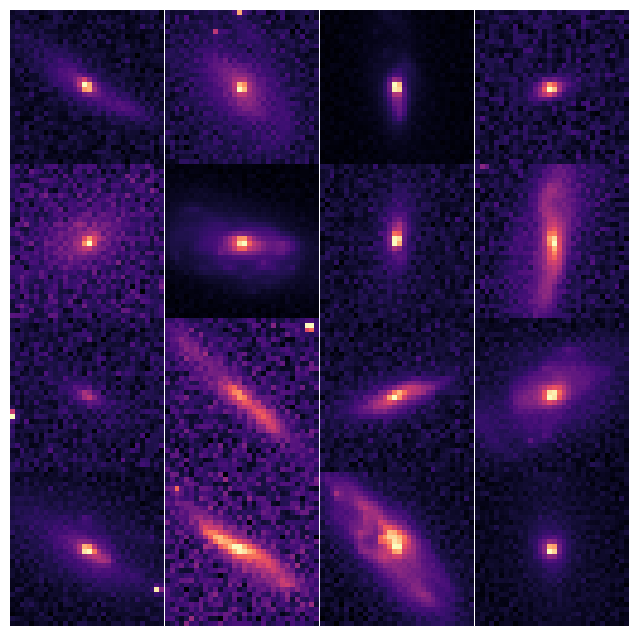

In [35]:
fig, axs = plt.subplots(4, 4, figsize=(8, 8))

for i in range(4):
    for j in range(4):
        k = i * 4 + j
        axs[i, j].imshow(samples[k, 0].cpu(), cmap="magma")
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)